In [28]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv('hotel_bookings.csv')
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)

Dataset shape: 119,390 rows, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [29]:
# Drop invalid records (zero guests, zero stay nights, negative/typo ADR)
invalid_mask = (
    ((df['adults'] + df['children'].fillna(0) + df['babies']) == 0) |
    ((df['stays_in_weekend_nights'] + df['stays_in_week_nights']) == 0) |
    (df['adr'] < 0) |
    (df['adr'] > 1000)
)
print(f"Dropping {invalid_mask.sum():,} invalid records...")
df_clean = df[~invalid_mask].copy()

# NOTE: We deliberately KEEP duplicate rows here rather than dropping them.
# EDA finding: 72% of duplicate rows come from Groups/Offline TA/TO market
# segments, which strongly suggests they represent genuine separate group
# bookings (e.g., wedding blocks, tour packages) that appear identical only
# because personal identifiers were stripped during anonymization.
# Dropping them would remove real signal and shift cancellation rate by ~10pp
# (37.04% -> 27.49%), disproportionately affecting Groups bookings.
#
# Instead, we prevent train/test leakage using a group-aware split later
# (GroupShuffleSplit), ensuring identical rows never appear in both sets.

print(f"Duplicate rows retained: {df_clean.duplicated().sum():,} "
      f"({df_clean.duplicated().sum() / len(df_clean) * 100:.2f}%)")
print("Decision: KEEP duplicates, apply group-aware train/test split downstream.")
print(f"Clean dataset shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

Dropping 827 invalid records...
Duplicate rows retained: 31,926 (26.93%)
Decision: KEEP duplicates, apply group-aware train/test split downstream.
Clean dataset shape: 118,563 rows, 32 columns


In [30]:
# Drop target leakage and post-booking features not available at reservation time
leakage_cols = [
    'reservation_status',
    'reservation_status_date',
    'assigned_room_type',
    'booking_changes',
    'days_in_waiting_list'
]
df_clean = df_clean.drop(columns=leakage_cols)
print(f"Remaining columns ({len(df_clean.columns)}):", df_clean.columns.tolist())

Remaining columns (27): ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [31]:
# Separate predictors and target
X = df_clean.drop(columns=['is_canceled'])
y = df_clean['is_canceled'].astype(int)

# Group ID based on identical booking profiles across all predictor columns
# dropna=False ensures records with nulls in agent/company/country are assigned a group ID
group_id = X.groupby(list(X.columns), dropna=False, sort=False).ngroup()

# Group-aware 80/20 train-test split (ensures identical group blocks never leak across splits)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=group_id))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# Verify zero cross-split leakage
train_groups = set(group_id.iloc[train_idx])
test_groups = set(group_id.iloc[test_idx])
overlap = len(train_groups.intersection(test_groups))

print(f"Total unique booking profile groups: {group_id.nunique():,}")
print(f"X_train: {X_train.shape[0]:,} rows ({len(train_idx)/len(X)*100:.2f}%) | cancellation rate: {y_train.mean():.4f}")
print(f"X_test:  {X_test.shape[0]:,} rows ({len(test_idx)/len(X)*100:.2f}%) | cancellation rate: {y_test.mean():.4f}")
print(f"Group overlap between train and test: {overlap} (no data leakage)")

Total unique booking profile groups: 84,287
X_train: 94,509 rows (79.71%) | cancellation rate: 0.3717
X_test:  24,054 rows (20.29%) | cancellation rate: 0.3761
Group overlap between train and test: 0 (no data leakage)


In [32]:
# Programmatic scan across categorical features for hidden placeholders
cat_cols_raw = X_train.select_dtypes(include=['object', 'string']).columns
placeholder_terms = ['Undefined', 'Unknown', '?', 'None', '-', '']
placeholder_records = []
for col in cat_cols_raw:
    for term in placeholder_terms:
        count = (X_train[col].astype(str).str.strip() == term).sum()
        if count > 0:
            placeholder_records.append({
                'Column': col,
                'Placeholder': term,
                'Count': count,
                'Percentage (%)': round((count / len(X_train)) * 100, 4)
            })
print("Detected Categorical Placeholders in X_train:")
print(pd.DataFrame(placeholder_records).to_string(index=False))

# Compute imputation statistics on training data only
med_children = X_train['children'].median()
mode_market = X_train['market_segment'].mode()[0]
mode_channel = X_train['distribution_channel'].mode()[0]

def impute_missing(data):
    df_out = data.copy()
    df_out['children'] = df_out['children'].fillna(med_children)
    df_out['country'] = df_out['country'].fillna('Unknown')
    df_out['agent'] = df_out['agent'].fillna(0)
    df_out['company'] = df_out['company'].fillna(0)
    df_out['meal'] = df_out['meal'].replace({'Undefined': 'SC'})
    df_out['market_segment'] = df_out['market_segment'].replace({'Undefined': mode_market})
    df_out['distribution_channel'] = df_out['distribution_channel'].replace({'Undefined': mode_channel})
    return df_out

X_train = impute_missing(X_train)
X_test = impute_missing(X_test)

print("\nRemaining NaNs in X_train:", X_train.isna().sum().sum())
print("Remaining NaNs in X_test: ", X_test.isna().sum().sum())

Detected Categorical Placeholders in X_train:
              Column Placeholder  Count  Percentage (%)
                meal   Undefined    946          1.0010
      market_segment   Undefined      2          0.0021
distribution_channel   Undefined      4          0.0042

Remaining NaNs in X_train: 0
Remaining NaNs in X_test:  0


In [33]:
def engineer_features(data):
    df_out = data.copy()
    
    # Stay metrics
    df_out['total_stay_nights'] = df_out['stays_in_weekend_nights'] + df_out['stays_in_week_nights']
    df_out['weekend_stay_ratio'] = df_out['stays_in_weekend_nights'] / np.maximum(df_out['total_stay_nights'], 1)
    
    # Guest composition
    df_out['total_guests'] = df_out['adults'] + df_out['children'] + df_out['babies']
    df_out['is_alone'] = (df_out['total_guests'] == 1).astype(int)
    df_out['is_family'] = ((df_out['children'] + df_out['babies']) > 0).astype(int)
    
    # Pricing
    df_out['adr_per_person'] = df_out['adr'] / np.maximum(df_out['total_guests'], 1)
    df_out['is_zero_adr'] = (df_out['adr'] == 0).astype(int)
    
    # Log-transformed lead time
    df_out['lead_time_log'] = np.log1p(df_out['lead_time'])
    
    # Cyclical seasonality
    month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
                 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
    month_num = df_out['arrival_date_month'].map(month_map).fillna(1).astype(int)
    df_out['arrival_month_sin'] = np.sin(2 * np.pi * month_num / 12)
    df_out['arrival_month_cos'] = np.cos(2 * np.pi * month_num / 12)
    df_out['arrival_season'] = month_num.map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    })
    
    # Affiliation flags
    df_out['has_agent'] = (df_out['agent'] != 0).astype(int)
    df_out['has_company'] = (df_out['company'] != 0).astype(int)
    
    # Prior history
    total_prev = df_out['previous_cancellations'] + df_out['previous_bookings_not_canceled']
    df_out['cancellation_ratio'] = df_out['previous_cancellations'] / (total_prev + 1)
    df_out['has_previous_cancellation'] = (df_out['previous_cancellations'] > 0).astype(int)
    
    # Service commitments
    df_out['has_parking_space'] = (df_out['required_car_parking_spaces'] > 0).astype(int)
    df_out['has_special_requests'] = (df_out['total_of_special_requests'] > 0).astype(int)
    
    return df_out

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)
print(f"Features after engineering: {X_train.shape[1]} columns")

Features after engineering: 43 columns


In [7]:
# Group top 15 countries and top 10 agents from X_train
top_countries = X_train['country'].value_counts().head(15).index.tolist()
top_agents = X_train[X_train['agent'] != 0]['agent'].value_counts().head(10).index.tolist()

def group_categories(data):
    df_out = data.copy()
    df_out['country_grouped'] = df_out['country'].apply(lambda x: x if x in top_countries else 'Other')
    
    def map_agent(val):
        if val == 0:
            return 'Direct'
        elif val in top_agents:
            return f"Agent_{int(val)}"
        else:
            return 'Other_Agent'
    df_out['agent_grouped'] = df_out['agent'].apply(map_agent)
    
    cols_to_drop = ['country', 'agent', 'company', 'arrival_date_month', 'arrival_date_year', 'arrival_date_day_of_month']
    return df_out.drop(columns=[c for c in cols_to_drop if c in df_out.columns])

X_train = group_categories(X_train)
X_test = group_categories(X_test)

cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 
            'deposit_type', 'customer_type', 'country_grouped', 'agent_grouped', 'arrival_season']
num_cols = [c for c in X_train.columns if c not in cat_cols]

# One-hot encode categoricals
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])
encoded_cols = ohe.get_feature_names_out(cat_cols).tolist()

X_train_ohe = pd.DataFrame(ohe.transform(X_train[cat_cols]), columns=encoded_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test[cat_cols]), columns=encoded_cols, index=X_test.index)

# Assemble unscaled feature matrix (for tree models)
X_train_tree = pd.concat([X_train[num_cols], X_train_ohe], axis=1)
X_test_tree = pd.concat([X_test[num_cols], X_test_ohe], axis=1)

print(f"Total features after encoding: {X_train_tree.shape[1]} (29 numeric, {len(encoded_cols)} one-hot encoded)")

Total features after encoding: 94 (29 numeric, 65 one-hot encoded)


In [8]:
# Winsorize ADR at 99th percentile and scale numeric features for linear models
p99_adr = X_train['adr'].quantile(0.99)

def winsorize_numerics(data):
    df_out = data.copy()
    df_out['adults'] = np.clip(df_out['adults'], 1, 4)
    df_out['children'] = np.clip(df_out['children'], 0, 3)
    df_out['babies'] = np.clip(df_out['babies'], 0, 2)
    df_out['adr'] = np.clip(df_out['adr'], 0, p99_adr)
    df_out['adr_per_person'] = np.clip(df_out['adr_per_person'], 0, p99_adr)
    return df_out

X_train_winsor = winsorize_numerics(X_train[num_cols])
X_test_winsor = winsorize_numerics(X_test[num_cols])

scaler = StandardScaler()
X_train_scaled_num = pd.DataFrame(scaler.fit_transform(X_train_winsor), columns=num_cols, index=X_train.index)
X_test_scaled_num = pd.DataFrame(scaler.transform(X_test_winsor), columns=num_cols, index=X_test.index)

# Assemble standardized matrix (for linear/distance models)
X_train_scaled = pd.concat([X_train_scaled_num, X_train_ohe], axis=1)
X_test_scaled = pd.concat([X_test_scaled_num, X_test_ohe], axis=1)

print("Unscaled tree matrix shape: ", X_train_tree.shape)
print("Standardized matrix shape:  ", X_train_scaled.shape)

Unscaled tree matrix shape:  (94509, 94)
Standardized matrix shape:   (94509, 94)


Top 10 features:
  1. deposit_type_No Deposit       : 0.1386
  2. deposit_type_Non Refund       : 0.1166
  3. country_grouped_PRT           : 0.0884
  4. lead_time_log                 : 0.0584
  5. lead_time                     : 0.0479
  6. cancellation_ratio            : 0.0474
  7. total_of_special_requests     : 0.0418
  8. has_previous_cancellation     : 0.0395
  9. agent_grouped_Agent_9         : 0.0388
 10. has_special_requests          : 0.0364


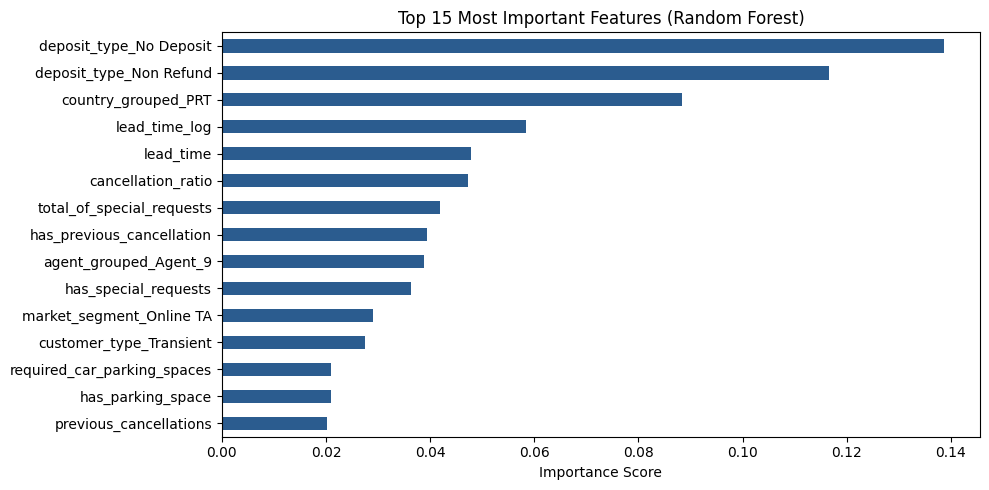

In [9]:
# Quick Random Forest baseline to rank feature importances
rf = RandomForestClassifier(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train_tree.columns).sort_values(ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 5))
importances.head(15).sort_values().plot(kind='barh', color='#2b5c8f')
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Save top 30 features list for ablation experiments
top_30_features = importances.head(30).index.tolist()
with open('models/selected_features.json', 'w') as f:
    json.dump(top_30_features, f, indent=4)

print("Top 10 features:")
for rank, (feat, score) in enumerate(importances.head(10).items(), 1):
    print(f" {rank:2d}. {feat:30s}: {score:.4f}")

In [34]:
# Save CSV datasets
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train_tree.to_csv('data/X_train_tree.csv', index=False)
X_test_tree.to_csv('data/X_test_tree.csv', index=False)
X_train_scaled.to_csv('data/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('data/X_test_scaled.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

# Save pipeline object for backend deployment
pipeline_bundle = {
    'top_countries': top_countries,
    'top_agents': top_agents,
    'med_children': med_children,
    'mode_market': mode_market,
    'mode_channel': mode_channel,
    'p99_adr': p99_adr,
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'feature_names': X_train_tree.columns.tolist(),
    'one_hot_encoder': ohe,
    'scaler': scaler
}
joblib.dump(pipeline_bundle, 'models/preprocessor_pipeline.joblib')

print("Preprocessing complete! All datasets and pipeline artifacts saved successfully.")

Preprocessing complete! All datasets and pipeline artifacts saved successfully.
